In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import random
import json
import os
import pickle
from dotenv import load_dotenv

# PyTorch (Neural Network) - Import this BEFORE using it for seeding
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn & Imblearn (Data Prep & Ensemble)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    brier_score_loss,
    log_loss,
)
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingClassifier

# Fairness
from fairlearn.metrics import demographic_parity_difference

# LLM explanation layer
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

warnings.filterwarnings('ignore')

# Reproducibility (best-effort)
np.random.seed(42)
random.seed(42)
# Now torch is defined, so this will work:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Data Ingestion & Cleaning

In [81]:
# Load datasets using project-relative paths (works from workspace root or model folder)
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

data_dir = project_root / 'data'

df1 = pd.read_excel(data_dir / 'case_study1.xlsx')
df2 = pd.read_excel(data_dir / 'case_study2.xlsx')

print(f"Project root resolved to: {project_root}")
print(f"Original df1 shape: {df1.shape}")
print(f"Original df2 shape: {df2.shape}")

Project root resolved to: c:\Users\KIIT0001\Desktop\Credit Scoring
Original df1 shape: (51336, 26)
Original df2 shape: (51336, 62)


In [82]:
#  Modernized -99999 Placeholder Cleaning (Vectorized for Speed)
df1.replace(-99999, np.nan, inplace=True)
df2.replace(-99999, np.nan, inplace=True)

# Clean df1: Drop rows missing the oldest tradeline age
df1.dropna(subset=['Age_Oldest_TL'], inplace=True)

# Clean df2: Drop columns with > 10,000 missing values
min_valid_count = len(df2) - 10000
df2.dropna(axis=1, thresh=min_valid_count, inplace=True)

# Clean df2: Drop remaining rows with any missing values
df2.dropna(inplace=True)

# Merging
df = pd.merge(df1, df2, how='inner', on=['PROSPECTID'])
print(f"Merged Clean Shape: {df.shape}")

Merged Clean Shape: (42064, 79)


## Feature Engineering and Multiclass SMOTE

In [83]:
# Drop PROSPECTID and the leaked Credit_Score column
df = df.drop(['PROSPECTID', 'Credit_Score'], axis=1, errors='ignore')

In [84]:
# Categorical vs Numerical Separation
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'Approved_Flag' in categorical_cols:
    categorical_cols.remove('Approved_Flag')

In [85]:
#  One-Hot Encoding (dtype=int fixes Python 3.13 Pandas behavior)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

#  Target & Feature Separation
X = df_encoded.drop('Approved_Flag', axis=1)
y = df_encoded['Approved_Flag']
X = X.astype(float)

# Encode the Target (P1, P2, P3, P4 -> 0, 1, 2, 3)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [86]:
# Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [87]:
# Leakage-safe CV: SMOTE is applied inside each fold via imblearn Pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    ))
])

cv_scoring = {
    'f1_weighted': 'f1_weighted',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr_weighted': 'roc_auc_ovr_weighted'
}

cv_results = cross_validate(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1
)

print('Leakage-safe CV summary (SMOTE inside each fold):')
print(f"Weighted F1: {cv_results['test_f1_weighted'].mean():.4f} +/- {cv_results['test_f1_weighted'].std():.4f}")
print(f"Macro F1:    {cv_results['test_f1_macro'].mean():.4f} +/- {cv_results['test_f1_macro'].std():.4f}")
print(f"ROC-AUC OVR: {cv_results['test_roc_auc_ovr_weighted'].mean():.4f} +/- {cv_results['test_roc_auc_ovr_weighted'].std():.4f}")

# Keep SMOTE for neural-network training set only (no CV leakage here)
smote_nn = SMOTE(random_state=42)
X_train_nn, y_train_nn = smote_nn.fit_resample(X_train, y_train)
print(f"Neural-net training rows after SMOTE: {X_train_nn.shape[0]}")

Leakage-safe CV summary (SMOTE inside each fold):
Weighted F1: 0.7682 +/- 0.0029
Macro F1:    0.6942 +/- 0.0053
ROC-AUC OVR: 0.9183 +/- 0.0014
Neural-net training rows after SMOTE: 81448


In [88]:
# Standardization for neural network branch only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nn)
X_test_scaled = scaler.transform(X_test)

# Keep unscaled DataFrame versions for tree-based ensemble branch
df_X_train_for_ensemble = X_train.copy()
df_X_test_for_ensemble = X_test.copy()

## Training the 60% Stacking Ensemble

In [89]:
print('Training the 60% Stacking Ensemble')

# Define base models
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced_subsample',
    random_state=42
)
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)
hist_model = HistGradientBoostingClassifier(
    max_iter=150,
    max_depth=6,
    random_state=42
)

Training the 60% Stacking Ensemble


In [90]:
# Build the Stacking Classifier
ensemble_60 = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('hist', hist_model)],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    cv=5,
    n_jobs=-1
)

In [91]:
# Train the base ensemble on original (non-SMOTE-expanded) training data
ensemble_60.fit(df_X_train_for_ensemble, y_train)

# Calibrate ensemble probabilities to improve confidence reliability
calibrated_ensemble = CalibratedClassifierCV(
    estimator=ensemble_60,
    method='sigmoid',
    cv=3,
    n_jobs=-1
)
calibrated_ensemble.fit(df_X_train_for_ensemble, y_train)

# Extract calibrated probability predictions for the test set
ensemble_probs = ensemble_60.predict_proba(df_X_test_for_ensemble)
ensemble_probs_calibrated = calibrated_ensemble.predict_proba(df_X_test_for_ensemble)
print('Ensemble training and calibration complete!')

Ensemble training and calibration complete!


## Building & Training the 40% PyTorch Neural Network

In [92]:
print('Training the 40% PyTorch Neural Network')

# Convert data to PyTorch tensors (SMOTE-balanced set for NN branch)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train_nn)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

Training the 40% PyTorch Neural Network


In [93]:
# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [94]:
# Define the Deep Learning Architecture
class CreditScoreNN(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super(CreditScoreNN, self).__init__()
        # Input Layer -> Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # Prevents overfitting
        
        # Hidden Layer 1 -> Hidden Layer 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        
        # Hidden Layer 2 -> Output Layer
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x) # No Softmax here; CrossEntropyLoss applies it internally during training
        return x

In [95]:
# Initialize model, class-weighted loss function, and optimizer
input_dim = X_train_scaled.shape[1]
nn_40 = CreditScoreNN(input_dim=input_dim)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

# Explicitly upweight P3 to improve minority-class separation
if 'P3' in label_encoder.classes_:
    p3_idx = int(np.where(label_encoder.classes_ == 'P3')[0][0])
    class_weights[p3_idx] *= 1.35

class_weights_tensor = torch.FloatTensor(class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(nn_40.parameters(), lr=0.001)

In [96]:
# Training Loop
epochs = 20
for epoch in range(epochs):
    nn_40.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = nn_40(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# Extract Probability Predictions from PyTorch Model
nn_40.eval() # Set to evaluation mode
with torch.no_grad():
    nn_raw_outputs = nn_40(X_test_tensor)
    # Apply softmax to get final probabilities (0 to 1)
    nn_probs = torch.softmax(nn_raw_outputs, dim=1).numpy()

print("PyTorch Training Complete!")

Epoch 5/20 - Loss: 0.4946
Epoch 10/20 - Loss: 0.4568
Epoch 15/20 - Loss: 0.4328
Epoch 20/20 - Loss: 0.4159
PyTorch Training Complete!


## The 60/40 Soft Voting Architecture & Evaluation

In [97]:
print('Merging Architectures: 60% Ensemble + 40% Neural Network')

# Use calibrated ensemble probabilities when available
ensemble_component = ensemble_probs_calibrated if 'ensemble_probs_calibrated' in globals() else ensemble_probs

# Apply the 60/40 weighting to the probabilities
final_probs = (0.6 * ensemble_component) + (0.4 * nn_probs)

# Get the final class prediction (the class with the highest combined probability)
y_pred_final = np.argmax(final_probs, axis=1)

Merging Architectures: 60% Ensemble + 40% Neural Network


In [98]:
# Evaluation metrics
print('\nClassification Report (60/40 Hybrid Model):')
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))

# Core discrimination metrics
f1 = f1_score(y_test, y_pred_final, average='weighted')
roc_auc = roc_auc_score(y_test, final_probs, multi_class='ovr', average='weighted')

# Calibration diagnostics
y_test_one_hot = np.eye(len(label_encoder.classes_))[y_test]
multiclass_brier = np.mean(np.sum((final_probs - y_test_one_hot) ** 2, axis=1))
model_log_loss = log_loss(y_test, final_probs)

print(f"Weighted F1-Score: {f1:.4f}")
print(f"Weighted ROC-AUC:  {roc_auc:.4f}")
print(f"Multiclass Brier Score: {multiclass_brier:.4f}")
print(f"Log Loss: {model_log_loss:.4f}")

print('\nPer-class Brier Scores:')
for class_idx, class_name in enumerate(label_encoder.classes_):
    class_brier = brier_score_loss(
        y_true=(y_test == class_idx).astype(int),
        y_proba=final_probs[:, class_idx]
    )
    print(f"{class_name}: {class_brier:.4f}")


Classification Report (60/40 Hybrid Model):
              precision    recall  f1-score   support

          P1       0.80      0.82      0.81       982
          P2       0.84      0.90      0.87      5090
          P3       0.42      0.36      0.39      1288
          P4       0.80      0.69      0.74      1053

    accuracy                           0.78      8413
   macro avg       0.72      0.69      0.70      8413
weighted avg       0.77      0.78      0.77      8413

Weighted F1-Score: 0.7723
Weighted ROC-AUC:  0.9194
Multiclass Brier Score: 0.2931
Log Loss: 0.5059

Per-class Brier Scores:
P1: 0.0313
P2: 0.1113
P3: 0.1081
P4: 0.0424


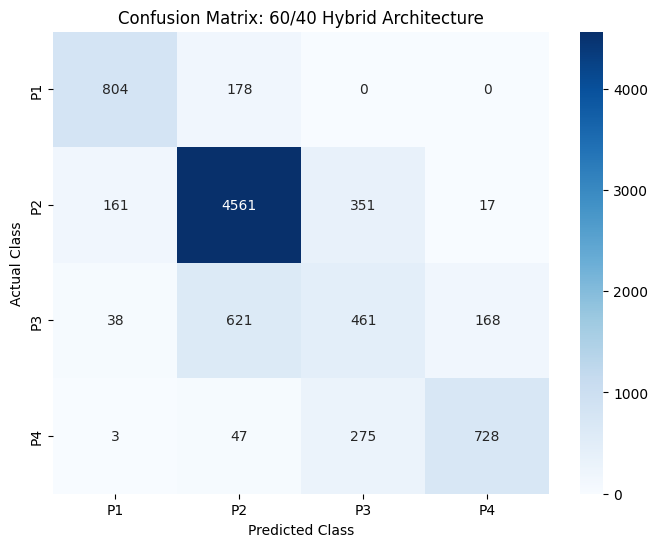

In [99]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix: 60/40 Hybrid Architecture')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

Investigating Potential Data Leakage


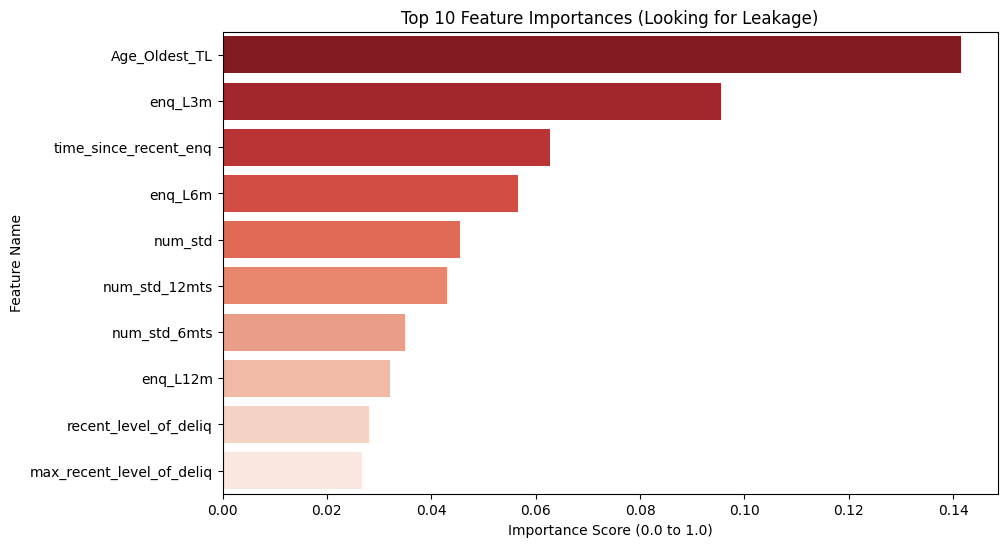


Top 5 Features by Weight:
Age_Oldest_TL            0.141429
enq_L3m                  0.095487
time_since_recent_enq    0.062820
enq_L6m                  0.056543
num_std                  0.045593
dtype: float64


In [100]:
print('Investigating Potential Data Leakage')

# Extract the trained Random Forest model from the stacking ensemble
fitted_rf = ensemble_60.named_estimators_['rf']

# Map feature importances to the ensemble input feature names
importances = pd.Series(
    fitted_rf.feature_importances_,
    index=df_X_train_for_ensemble.columns
)

# Sort and plot the top 10 most important features
top_10_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='Reds_r')
plt.title('Top 10 Feature Importances (Looking for Leakage)')
plt.xlabel('Importance Score (0.0 to 1.0)')
plt.ylabel('Feature Name')
plt.show()

print('\nTop 5 Features by Weight:')
print(top_10_features.head(5))

## Explainability with SHAP

Generating SHAP Explainability


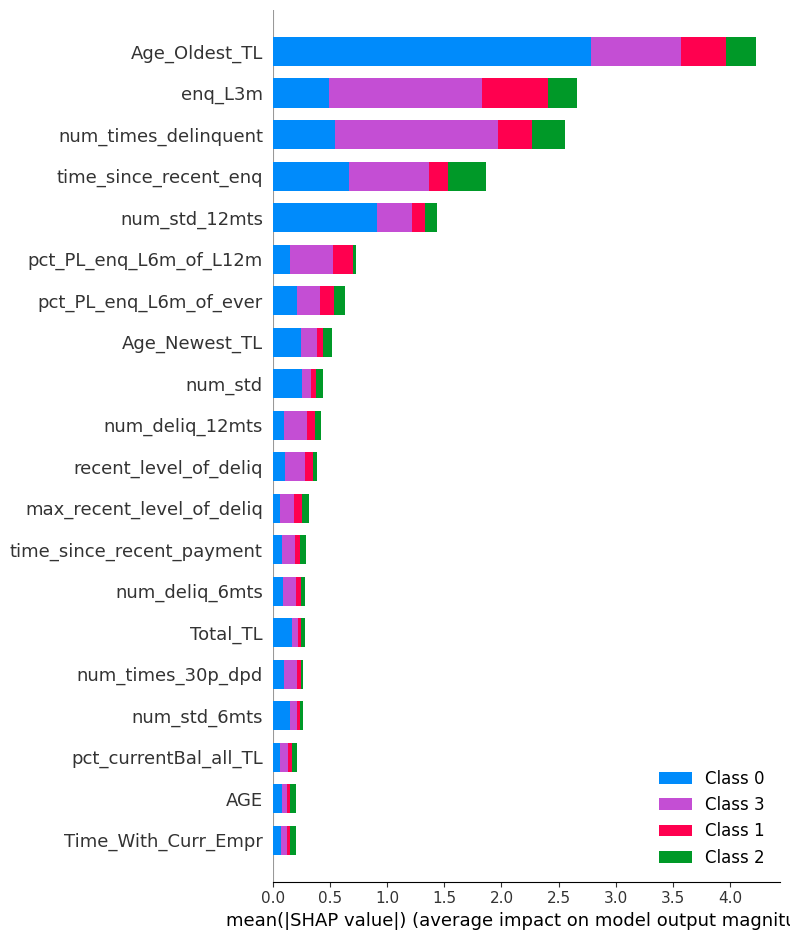

SHAP extraction ready for LLM integration.


In [101]:
print('Generating SHAP Explainability')
import shap

# Extract the fitted XGBoost model directly from the trained ensemble
fitted_xgb = ensemble_60.named_estimators_['xgb']

# Initialize the TreeExplainer using the fitted model
explainer = shap.TreeExplainer(fitted_xgb)

# Calculate SHAP values for a sample of the test set
X_test_sample = df_X_test_for_ensemble.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Plot global feature importance
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

print('SHAP extraction ready for LLM integration.')

## Fairness Auditing (Demographic Parity)

In [102]:
print('Professional Multi-Dimension Fairness Audit')

# Helper: build a single categorical sensitive feature from one-hot columns
def build_sensitive_from_one_hot(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return None
    sub = df[cols]
    labels = sub.idxmax(axis=1)
    labels = labels.where(sub.sum(axis=1) > 0, 'Unknown')
    return labels

Professional Multi-Dimension Fairness Audit


In [103]:
# Helper: find a numeric age column in X_test
age_cols = [c for c in X_test.columns if 'age' in c.lower()]
age_sensitive = None
if age_cols:
    age_sensitive = (X_test[age_cols[0]] < 30).astype(int)

In [104]:
# Build sensitive attributes from unscaled test features
# (one-hot columns preserve semantic group identity only before scaling)
audit_dict = {}
gender_sensitive = build_sensitive_from_one_hot(X_test, 'GENDER_')
if gender_sensitive is not None:
    audit_dict['Gender'] = gender_sensitive

marital_sensitive = build_sensitive_from_one_hot(X_test, 'MARITALSTATUS_')
if marital_sensitive is not None:
    audit_dict['Marital Status'] = marital_sensitive

race_sensitive = build_sensitive_from_one_hot(X_test, 'RACE_')
if race_sensitive is not None:
    audit_dict['Race'] = race_sensitive

class_sensitive = build_sensitive_from_one_hot(X_test, 'CLASS_')
if class_sensitive is not None:
    audit_dict['Class'] = class_sensitive

student_sensitive = build_sensitive_from_one_hot(X_test, 'STUDENT_')
if student_sensitive is not None:
    audit_dict['Student'] = student_sensitive

if age_sensitive is not None:
    audit_dict['Age (<30 vs >=30)'] = age_sensitive

if not audit_dict:
    print('No sensitive attributes found. Skipping fairness audit.')
else:
    for attribute, data in audit_dict.items():
        dp_diff = demographic_parity_difference(
            y_true=y_test,
            y_pred=y_pred_final,
            sensitive_features=data
        )
        print(f'Demographic Parity Difference for {attribute}: {dp_diff:.4f}')
        if dp_diff < 0.07:
            print(f'PASS: Model is fair regarding {attribute}.')
        else:
            print(f'FAIL: Bias detected in {attribute}!')
        print('-' * 50)

Demographic Parity Difference for Gender: 0.0221
PASS: Model is fair regarding Gender.
--------------------------------------------------
Demographic Parity Difference for Marital Status: 0.0082
PASS: Model is fair regarding Marital Status.
--------------------------------------------------
Demographic Parity Difference for Age (<30 vs >=30): 0.0184
PASS: Model is fair regarding Age (<30 vs >=30).
--------------------------------------------------


In [105]:
# Save artifacts and define a reusable inference helper
artifacts_dir = project_root / 'model' / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(artifacts_dir / 'hybrid_preprocessing.pkl', 'wb') as f:
    pickle.dump(
        {
            'label_encoder': label_encoder,
            'feature_columns': X.columns.tolist(),
            'scaler': scaler,
            'categorical_cols': categorical_cols,
            'blend_weights': (0.6, 0.4),
            'calibrated_ensemble': calibrated_ensemble,
        },
        f,
    )

torch.save(nn_40.state_dict(), artifacts_dir / 'nn_40_state_dict.pt')

with open(artifacts_dir / 'model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'classes': label_encoder.classes_.tolist(),
            'input_dim': int(input_dim),
            'n_features': int(len(X.columns)),
            'weights': {'ensemble': 0.6, 'nn': 0.4},
        },
        f,
        indent=2,
    )


def predict_credit_approval(raw_df: pd.DataFrame) -> pd.DataFrame:
    data = raw_df.copy()
    data = data.drop(columns=['PROSPECTID', 'Credit_Score'], errors='ignore')

    encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)
    encoded = encoded.reindex(columns=X.columns, fill_value=0).astype(float)

    ensemble_probs_local = calibrated_ensemble.predict_proba(encoded)

    nn_input = torch.FloatTensor(scaler.transform(encoded))
    nn_40.eval()
    with torch.no_grad():
        nn_probs_local = torch.softmax(nn_40(nn_input), dim=1).numpy()

    blended = (0.6 * ensemble_probs_local) + (0.4 * nn_probs_local)
    pred_idx = np.argmax(blended, axis=1)
    pred_label = label_encoder.inverse_transform(pred_idx)

    result = pd.DataFrame({'predicted_label': pred_label, 'confidence': blended.max(axis=1)})
    for i, class_name in enumerate(label_encoder.classes_):
        result[f'prob_{class_name}'] = blended[:, i]

    return result


print(f'Artifacts saved to: {artifacts_dir}')
print('Inference helper ready: predict_credit_approval(raw_df)')

Artifacts saved to: c:\Users\KIIT0001\Desktop\Credit Scoring\model\artifacts
Inference helper ready: predict_credit_approval(raw_df)


In [106]:
# GenAI output: only Accepted/Rejected decision reason
def _top_local_drivers_for_class(shap_obj, feature_names, class_index, top_k=3):
    arr = np.asarray(shap_obj)

    if isinstance(shap_obj, list):
        class_values = np.asarray(shap_obj[class_index])
        row_values = class_values[0] if class_values.ndim == 2 else class_values
    elif arr.ndim == 3:
        # Common shape: (samples, features, classes)
        if arr.shape[2] > class_index:
            row_values = arr[0, :, class_index]
        else:
            # Alternate shape: (classes, samples, features)
            row_values = arr[class_index, 0, :]
    elif arr.ndim == 2:
        row_values = arr[0]
    else:
        raise ValueError('Unsupported SHAP format for local explanation.')

    contrib = pd.Series(np.abs(row_values), index=feature_names)
    return contrib.sort_values(ascending=False).head(top_k).index.tolist()

In [107]:
# Load Gemini key from .env (supports common key names)
dotenv_path = (project_root / '.env') if 'project_root' in globals() else (Path.cwd().parent / '.env')
if not dotenv_path.exists():
    dotenv_path = Path.cwd() / '.env'
load_dotenv(dotenv_path)

gemini_api_key = (
    os.getenv('GEMINI_API_KEY')
    or os.getenv('GOOGLE_API_KEY')
    or os.getenv('GOOGLE_GENAI_API_KEY')
)
if not gemini_api_key:
    raise ValueError('No Gemini API key found in .env. Set one of: GEMINI_API_KEY, GOOGLE_API_KEY, GOOGLE_GENAI_API_KEY.')


In [108]:

# Decision mapping assumption: last class is rejection bucket
rejection_label = label_encoder.classes_[-1]
rejection_class_index = int(np.where(label_encoder.classes_ == rejection_label)[0][0])

# Select a few cases to explain
example_indices = X_test.index[:5].tolist()

decision_explanations = []

candidate_models = [
    'gemini-2.5-flash',
    'gemini-2.0-flash',
    'gemini-1.5-flash',
]

selected_model = None
for model_name in candidate_models:
    try:
        llm = ChatGoogleGenerativeAI(
            model=model_name,
            google_api_key=gemini_api_key,
            temperature=0.2,
        )
        selected_model = model_name
        break
    except Exception:
        llm = None

if llm is None:
    raise RuntimeError('Could not initialize any Gemini model for decision explanations.')

In [109]:
prompt = ChatPromptTemplate.from_messages([
    (
        'system',
        'You explain only loan decision reason. Keep output very short and strict.'
    ),
    (
        'human',
        'Given the decision evidence, output exactly:\n'
        'Decision: <Accepted or Rejected>\n'
        'Reason: <one short sentence with the top 2-3 factors>\n\n'
        'Evidence:\n{evidence_json}'
    ),
])

In [110]:
for idx in example_indices:
    row = X_test.loc[[idx]]
    probs = final_probs[X_test.index.get_loc(idx)]
    pred_idx = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    decision = 'Rejected' if pred_idx == rejection_class_index else 'Accepted'

    shap_single = explainer.shap_values(row)
    top_drivers = _top_local_drivers_for_class(
        shap_single,
        row.columns,
        class_index=pred_idx,
        top_k=3,
    )

    evidence = {
        'predicted_label': str(pred_label),
        'decision': decision,
        'confidence': float(np.max(probs)),
        'top_drivers': top_drivers,
    }

    message = prompt.format_messages(evidence_json=json.dumps(evidence, indent=2))
    response = llm.invoke(message)
    decision_explanations.append(
        {
            'row_index': int(idx),
            'decision_explanation': response.content.strip(),
        }
    )



In [111]:
# Save and print only decision explanations
report_dir = project_root / 'model' / 'artifacts'
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / 'llm_decision_explanations.md'

report_lines = [f'LLM model used: {selected_model}', '']
for item in decision_explanations:
    report_lines.append(f"Case {item['row_index']}")
    report_lines.append(item['decision_explanation'])
    report_lines.append('')

report_text = '\n'.join(report_lines)
report_path.write_text(report_text, encoding='utf-8')

print(report_text)
print(f'Saved: {report_path}')

LLM model used: gemini-2.5-flash

Case 41161
Decision: Accepted
Reason: Low number of times delinquent, few inquiries in the last 3 months, and old age of oldest trade line.

Case 1164
Decision: Accepted
Reason: Age of oldest trade line, number of times delinquent, and number of standard deviations in 12 months.

Case 27276
Decision: Accepted
Reason: Strongest factors were Age_Oldest_TL, time_since_recent_enq, and Age_Newest_TL.

Case 15763
Decision: Accepted
Reason: Top factors are enq_L3m, Age_Oldest_TL, and time_since_recent_payment.

Case 24887
Decision: Accepted
Reason: Low number of times delinquent, few inquiries in the last 3 months, and older age of oldest trade line.

Saved: c:\Users\KIIT0001\Desktop\Credit Scoring\model\artifacts\llm_decision_explanations.md
